<a href="https://colab.research.google.com/github/rakeshgomadi96/Forecasting-Projects-using-LLM/blob/main/PROJECT_GOLD_DATASET(2)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pmdarima

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,7)
import seaborn as sns
sns.set_style('darkgrid')
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
%matplotlib inline

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/rizwin7/DATASCIENCE/main/Gold_data.csv')
df

,date,price
0,2016-01-01,2252.60
1,2016-01-02,2454.50
2,2016-01-03,2708.10
3,2016-01-04,2577.80
4,2016-01-05,2597.75
...,...,...
2177,2021-12-17,4394.40
2178,2021-12-18,4389.50
2179,2021-12-19,4389.50
2180,2021-12-20,4354.10


# EDA

In [ ]:
# looking for the shape of the data
df.shape

(2182, 2)

In [ ]:
# We can see we have 6 years of data

In [ ]:
# checking the Descriptive Satats
df.describe()

,price
count,2182.000000
mean,3284.450046
std,719.564434
min,2252.600000
25%,2697.020000
50%,2879.800000
75%,4147.325000
max,4966.300000


In [ ]:
# here we observe min, max, stdv ,%tile of the price column
# price range is between 2252 to 4966
# by looking towards 75% & max we can say no outlier is there

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2182 non-null   object 
 1   price   2182 non-null   float64
dtypes: float64(1), object(1)
memory usage: 34.2+ KB


### Date Column Extraction

In [ ]:
df["Date"] = pd.to_datetime(df['date'],format="%Y-%m-%d")
df["month"] = df.Date.dt.strftime("%b") # month extraction
df["year"] = df.Date.dt.strftime("%Y")
df['days'] = df.Date.dt.strftime("%d")

In [ ]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

In [ ]:
months_dummies = pd.DataFrame(pd.get_dummies(df['month'],columns=months))
months_dummies

,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2177,False,False,True,False,False,False,False,False,False,False,False,False
2178,False,False,True,False,False,False,False,False,False,False,False,False
2179,False,False,True,False,False,False,False,False,False,False,False,False
2180,False,False,True,False,False,False,False,False,False,False,False,False


In [ ]:
df = pd.concat([df,months_dummies], axis = 1)

In [ ]:
df

In [ ]:
df.isna().sum()

In [ ]:
# the observation is there is [no] not null value,
# target column data type is float.


# Outlier Detection

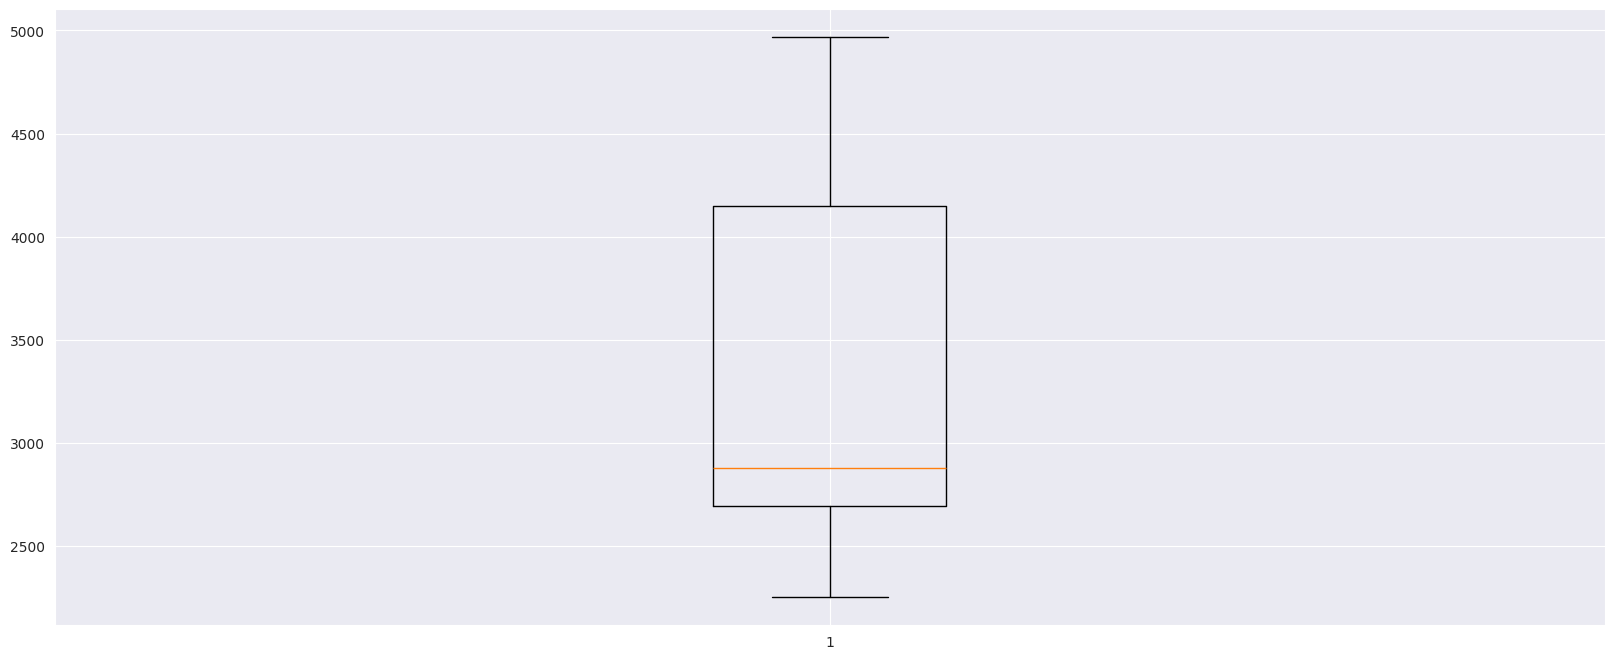

In [ ]:
plt.boxplot(df['price'])
plt.rcParams['figure.figsize'] = (10,7)

# Visualization

### Checking Trend

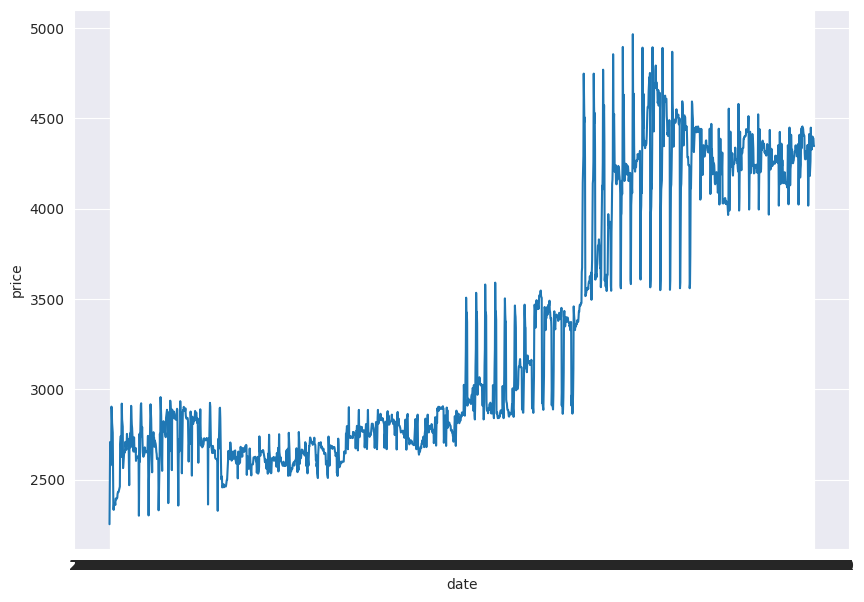

In [ ]:
sns.lineplot(x='date',y='price',data=df)
plt.rcParams['figure.figsize'] = (20,8)
plt.show()

# Checking Stationarity of the data

In [ ]:
adfuller(df['price'])[1]

Null hypothesis: Data is Non stationary

Alternate Hypothesis: Data is Stationary

If p< 0.05 ; Data is stationary

if p>0.05; Data is not stationary

According the p-value, the dataset is non-stationary as the p value is greater than alpha value.

In [ ]:
import  plotly.express  as pe

In [ ]:
plt.rcParams['figure.figsize'] = (20,8)
pe.line(x=df['date'],y=df['price'])

In [ ]:
#kde plot
df['price'].plot(kind='kde')
plt.rcParams['figure.figsize'] = (12,4)

 We can see that The graph is right skewed

In [ ]:
# boxplot to just confirm outliers present or not
plt.boxplot(df['price'])
plt.rcParams['figure.figsize'] = (10,7)

In [ ]:
# histogram
plt.hist(x=df['price'])
plt.rcParams['figure.figsize'] = (12,7)

 we have ploted histogram to check the range of the price. 2500 to 3100 is more & from 4300 to 4100 is more

In [ ]:
pip install calplot

In [ ]:
import calplot
df.index = pd.to_datetime(df['date'])
calplot.calplot(df['price'],edgecolor=None)

Cal Plot is similar as calender we can year/months/day Graph
Lighter color is for more price and darker color is for less price

In [ ]:
from pandas.plotting import lag_plot


In [ ]:
lag_plot(df['price'])

In [ ]:
df['first_order'] = df['price'].diff(periods=1)

In [ ]:
df

In [ ]:
df.dropna(inplace=True)

In [ ]:
df

In [ ]:
plt.plot(df['price'],color='black',label='price')
plt.plot(df['first_order'],color='red',label='first_order')
plt.legend()

# Auto Correlation Function ( ACF )

In [ ]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [ ]:
# Calculate Auto-Correlation value
acf_val = acf(df['first_order'])
acf_val

here we can see almost [ 32 ] period or step lag variable is 44% correlate with current data

In [ ]:
# Looking by ploting graph
plot_acf(df['first_order'],lags=100)
plt.show()

Here we can see the points near about 35 , 62 , 94 are crossing our Standred Error so we can say this are Statistical Significant

# Partial Auto Correlation Function ( PACF )

In [ ]:
# calculate pacf value
pacf_value = pacf(df['first_order'])
pacf_value

 Pacf will give which lag variable is directly impact on current data

In [ ]:
plot_pacf(df['first_order'],lags=100)
plt.show()

In [ ]:
df

In [ ]:
df['t'] = np.arange(0,2181)

In [ ]:
df['t_squared'] = df['t']*df['t']
df['log_price'] = np.log(df['price'])

In [ ]:
df

In [ ]:
df.drop(columns='date',inplace=True)

In [ ]:
# Speliting the data into train & test
train = df.head(2181)
test = df.tail(20)

In [ ]:
train.shape

In [ ]:
test.shape

## ARIMA Model

Finding with Auto Arima

In [ ]:
order = auto_arima(df['price'])

In [ ]:
order

##### AR model = There are 4 lag variable which are effecting my model
##### MA model = There are 5 order of Moving Average
##### d is [ 0 / zero ] bcz data is stationary          


In [ ]:
arima_model = ARIMA(train['price'],order=(5,1,5)).fit()
import warnings
warnings.filterwarnings('ignore')

## Evaluating the Model

In [ ]:
test

In [ ]:
ypred = arima_model.predict(start=2162,end=2181)
ypred

In [ ]:
print(np.sqrt(mean_squared_error(test['price'],ypred)))

In [ ]:
# Here we have Worst model BCZ we are looking for a close value to RMSE

In [ ]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error

# Linear Model

In [ ]:
linear_model  = smf.ols('price~t',data=df,).fit()
pred_linear = pd.Series(linear_model.predict(test['t']))
rmse_lm = np.sqrt(mean_squared_error(test['price'],pred_linear))
rmse_lm

# Quadratic Model

In [ ]:

quad_model = smf.ols('price~t+t_squared',data=train).fit()
pred_quad = quad_model.predict(test[["t", "t_squared"]])

rmse_quad = np.sqrt(mean_squared_error(test['price'],pred_quad))
rmse_quad

# Additive Seasonality

In [ ]:

as_model = smf.ols('price~ Jan + Feb + Mar + Apr + May + Jun + Jul + Aug + Sep + Oct + Nov', data=train).fit()
pred_as = as_model.predict(test[['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']])
rmse_as = np.sqrt(mean_squared_error(test['price'], pred_as))
rmse_as


# Additive Seasonality Quadratic¶

In [ ]:
asq_model = smf.ols('price~t+t_squared+Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data=train).fit()
pred_asq = pd.Series(asq_model.predict(test[['t','t_squared','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']]))
rmse_asq = np.sqrt(mean_squared_error(test['price'],pred_asq))
rmse_asq

# Multiplicative Seasonality

In [ ]:

Mul_sea = smf.ols('log_price~Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data = train).fit()
pred_Mult_sea = pd.Series(Mul_sea.predict(test))
rmse_ms = np.sqrt(mean_squared_error(test['log_price'],pred_Mult_sea))
rmse_ms

# Multiplicative Additive Seasonality

In [ ]:
Mul_Add_sea = smf.ols('log_price~t+Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data = train).fit()
pred_Mult_add_sea = pd.Series(Mul_Add_sea.predict(test))
rmse_mas = np.sqrt(mean_squared_error(test['log_price'],pred_Mult_add_sea))
rmse_mas

# Multiplicative Seasonality Quadratic¶

In [ ]:
mult_sea_Quad = smf.ols('log_price~Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data=train).fit()
pred_mult_sea_quad = pd.Series(mult_sea_Quad.predict(test[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']]))
rmse_msq = np.sqrt(mean_squared_error(test['log_price'],pred_Mult_add_sea))
rmse_msq

In [ ]:
data = {"MODEL":pd.Series(["rmse_linear","rmse_Quad","rmse_add_sea","rmse_add_sea_quad","rmse_Mult_sea","rmse_Mult_add_sea"]),"RMSE_Values":pd.Series([rmse_lm,rmse_quad,rmse_as,rmse_ms,rmse_mas])}
table_rmse=pd.DataFrame(data)
table_rmse.sort_values(['RMSE_Values'])

## Predicting for Next 30 Days By ARIMA Model

In [ ]:
# Generating Dates for next 30 days
next_30_days = pd.date_range(start=df.index[-1], periods=30, freq='D')
next_30_days

In [ ]:
# Perform the prediction using the ARIMA model
final_model = arima_model.predict(start=df.index[-1], end=next_30_days[-1])

In [ ]:
final_model

Saving the trained model


In [ ]:
import pandas as pd
import pmdarima as pm
import pickle

def train_arima_model(data_url):
# Load the data into a DataFrame
     df = pd.read_csv(data_url)

# Convert the 'Date' column to datetime and set it as the index
     df['Date'] = pd.to_datetime(df['date'])
     df.set_index('Date', inplace=True)

# Drop any missing values if present
     df.dropna(inplace=True)

# Identify the order of the ARIMA model using auto_arima from pmdarima
     model = pm.auto_arima(df['price'], seasonal=False, stepwise=True, suppress_warnings=True)

# Train the ARIMA model
     model.fit(df['price'])

# Save the trained ARIMA model using pickle
f = 'arima_model.pkl'
pickle.dump(model, open(f, 'wb'))

# if __name__ == '__main__':
   #data_url = 'https://raw.githubusercontent.com/rizwin7/DATASCIENCE/main/Gold_data.csv'

# Load the ARIMA model from pickle file
loaded_model = pickle.load(open('arima_model.pkl' , 'rb'))

# Function to predict next 30 days gold price
def predict_gold_price():
    forecast_period = 30
    forecast, conf_int = loaded_model.predict(n_periods=forecast_period, return_conf_int=True)

    # Create a DataFrame with appropriate date index
    forecast_index = pd.date_range(pd.to_datetime('today'), periods=forecast_period, closed='right')
    forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=['Gold_Price_Forecast'])

    return forecast_df

def main():
    st.title('Gold Price Prediction')
    st.write("Using ARIMA Model")

    # Predict the nexxt 30 days gold price
    forecast_df = predict_gold_price()

    # Display the forecast data
    st.write('Forecasted Gold Prices for the next 30 Days:')
    st.dataframe(forecast_df)

if __name__ == '__main__':
    main()

In [ ]:
# prompt: 5

print(5)
